In [1]:
%cd ../..
%env NEPTUNE_API_TOKEN="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MGUyNWNlYi1jYzlkLTQ4NjUtYjMxYi0yMWNlNDJiY2UwNzYifQ=="

/home/jj/Research/ConceptualSensitivityRegularization
env: NEPTUNE_API_TOKEN="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiI1MGUyNWNlYi1jYzlkLTQ4NjUtYjMxYi0yMWNlNDJiY2UwNzYifQ=="


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from csr.module.utils.notebookutils import NeptuneViewer
pd.options.display.float_format = '{:,.4f}'.format

/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/jj/anaconda3/envs/torch2.1_cuda11.8/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


# 1. Get DataFrame from Neptune project

In [9]:
project_name = '240401CatDog'
df = NeptuneViewer.get_neptune_dataframe('smoothAttributionPrior', project_name)
print('-'*20)
print(len(df))

cktp_list = df.query('module_name == "CGR"')['g_ckpt_path'].unique()
ckpt_svm = [i for i in cktp_list if 'svm' in i][0]
ckpt_signal = [i for i in cktp_list if 'signal' in i][0]
ckpt_cgr = [i for i in cktp_list if 'last' in i][0]

svm_idx = df.query('g_ckpt_path == @ckpt_svm').index
df.loc[svm_idx, 'module_name'] = 'RRC-SVM'

signal_idx = df.query('g_ckpt_path == @ckpt_signal').index
df.loc[signal_idx, 'module_name'] = 'RRC-Signal'

cgr_idx = df.query('g_ckpt_path == @ckpt_cgr').index
df.loc[cgr_idx, 'module_name'] = 'CGR'


# setting index
# jtt_idx = df.query('not eta.isnull()').index
# df.loc[jtt_idx, 'module_name'] = 'GDRO'

# erm_idx = df.query('module_name.isnull()').index
# df.loc[erm_idx, 'module_name'] = 'ERM'

[neptune] [info   ] Neptune initialized. Open in the app: https://app.neptune.ai/smoothAttributionPrior/240401CatDog/


Fetching table...: 0 [00:00, ?/s]

[neptune] [info   ] Shutting down background jobs, please wait a moment...
[neptune] [info   ] Done!
[neptune] [info   ] Explore the metadata in the Neptune app: https://app.neptune.ai/smoothAttributionPrior/240401CatDog/metadata
--------------------
240


# 2. Get accuracy table

## 2.1. ERM

# ERM results (Hparams search 1)
- batch_size: [16, 32]
- learning_rate: [1e-4, 3e-4, 1e-3, 3e-3]
- weight_decay: 1e-2
- beta: [10]
- seed: [1232, 1233, 1234]

> Double click this cell to see the shell script!

<!-- Our code

############################################################## ERM (Freeze, pretrained) #################################################################
OUTPUT_DIR='./output'
PROJECT_NAME='SpuriousWaterBirdERM'
ROOT_DIR=$OUTPUT_DIR'/'$PROJECT_NAME
# DATA_PATH='/mnt/ssd/jj/Research/Maxent/SmoothAttributionPrior/data/Waterbirds_epochs_2_imgnet_pretrained_targetlayer_classifier.2_seed_1234_augmentation_default.pt'
DATA_PATH='/dev/shm/Waterbirds_epochs_600_imgnet_pretrained_targetlayer_classifier.2_seed_1234_augmentation_default.pt'


MAIN_ARGS="--loggername neptune --dataset Waterbirds --litmodule feature_erm " # --seed 1234 
TRAINER_ARGS="--default_root_dir ${ROOT_DIR} --max_epochs 600 --accelerator gpu --devices 1 --log_every_n_steps 30 "
MODEL_ARGS="--model convnext_t --imagenet_pretrained True --freeze_model True --freezing_target_layer classifier.2 --set_last_layer three_layer --h_activation_fn softplus --h_softplus_beta 10" # 
CLS_ARGS="--scheduler cosineannealing --milestones 9999 --weight_decay 0.01 --optimizer adamw --criterion bce --pos_weight 3.31 --learning_rate 3e-3 " # 
F_ARGS="--del_backbone True "
DATA_ARGS="--num_workers 2 --tr_shuffle True --data_path ${DATA_PATH} --batch_size_test 100 --batch_size_train 16 " #"  --data_seed 1234 --minor_ratio 0.05


for SEED in 1232 1233 1234 1235 1236
do

CUDA_VISIBLE_DEVICES=0 python smoothAttributionPrior/spurious_feature_main.py $MAIN_ARGS $TRAINER_ARGS $MODEL_ARGS $CLS_ARGS $DATA_ARGS $F_ARGS \
--seed $SEED --data_seed $SEED --minor_ratio 0 &

CUDA_VISIBLE_DEVICES=1 python smoothAttributionPrior/spurious_feature_main.py $MAIN_ARGS $TRAINER_ARGS $MODEL_ARGS $CLS_ARGS $DATA_ARGS $F_ARGS \
--seed $SEED --data_seed $SEED --minor_ratio 0.001 &

CUDA_VISIBLE_DEVICES=2 python smoothAttributionPrior/spurious_feature_main.py $MAIN_ARGS $TRAINER_ARGS $MODEL_ARGS $CLS_ARGS $DATA_ARGS $F_ARGS \
--seed $SEED --data_seed $SEED --minor_ratio 0.005 &

CUDA_VISIBLE_DEVICES=3 python smoothAttributionPrior/spurious_feature_main.py $MAIN_ARGS $TRAINER_ARGS $MODEL_ARGS $CLS_ARGS $DATA_ARGS $F_ARGS \
--seed $SEED --data_seed $SEED --minor_ratio 0.01 &
wait

done
 -->

In [10]:
# A list of important columns, where hparams values are between 2 to 6.
important_columns = (df.nunique() > 1) & (df.nunique() < 7)
important_columns = [i for i in df.columns[important_columns] if 'acc' not in i]
print(important_columns)
print()
# print the unique values of the important columns
product = 1
for i in df[important_columns]:
    product *= len(df[i].unique())
    print(i, end=' = ')
    print(df[i].unique())
print()
print('Product of unique values of important columns: ', product)

['batch_size_train', 'data_seed', 'g_ckpt_path', 'g_model', 'learning_rate', 'minor_ratio', 'module_name', 'set_last_layer']

batch_size_train = [16 32]
data_seed = [1236 1235 1234]
g_ckpt_path = ['/mnt/ssd/jj/Research/Maxent/ConceptualSensitivityRegularization/.neptune/temp/TEM-585/checkpoints/last.ckpt'
 '/mnt/ssd/jj/Research/Maxent/ConceptualSensitivityRegularization/data/cavs/catdog_concepts_convnext_t_svm.pt'
 '/mnt/ssd/jj/Research/Maxent/ConceptualSensitivityRegularization/data/cavs/catdog_concepts_convnext_t_signal.pt'
 nan]
g_model = ['three_layer' 'linear' nan]
learning_rate = [0.003  0.0003 0.0001 0.001 ]
minor_ratio = [0.05 0.  ]
module_name = ['CGR' 'RRC-SVM' 'RRC-Signal' 'ERM']
set_last_layer = ['three_layer' 'linear']

Product of unique values of important columns:  4608


In [11]:
def mean_std(x):
    return f'{100*x.mean():.3f}+{100*x.std():.3f}'

def sort_and_query(df, sort_by, query):
    df_temp = df.sort_values(by=sort_by)
    df_temp = df_temp.query(query)
    return df_temp

def get_best_index(df, var_list, metric):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    idx = df_mean.reset_index().groupby(['minor_ratio']).idxmax()[metric].dropna()
    return idx

def get_mean_with_given_index(df, var_list, metric, idx):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    return df_mean.reset_index().loc[idx].set_index('minor_ratio')[metric]

def get_std_with_given_index(df, var_list, metric, idx):
    df_std = df.groupby(var_list)[metric].std().sort_index()
    return df_std.reset_index().loc[idx].set_index('minor_ratio')[metric]

def process_all(df, var_list, metric):
    idx = get_best_index(df, var_list, metric)
    mean = get_mean_with_given_index(df, var_list, metric, idx)
    std = get_std_with_given_index(df, var_list, metric, idx)
    return mean, std


# Prepare quaried and sorted dataframe

In [12]:
var_list = ['set_last_layer', 'minor_ratio', 'batch_size_train', 'data_seed', 'learning_rate']
index = var_list.copy()
index.remove('data_seed')
columns = ['data_seed']

query = ' and '.join(
    [
        'model == "convnext_t"',
        'module_name == "ERM"'
    ]
)
df_queried_erm = sort_and_query(df, var_list, query)

In [13]:
values = ['valid_valid_best_worst_acc']
df_pivot = df_queried_erm.pivot_table(index=index, columns=columns, values=values)
df_group = df_queried_erm.groupby(index)['valid_valid_best_worst_acc'].apply(mean_std)
df_cat = pd.concat((df_pivot, df_group), axis=1)
df_cat.columns = pd.Index([('valid_valid_best_worst_acc', i) for i in range(1234, 1237)] + [('valid_valid_best_worst_acc', 'mean std')])
df_cat

valid_valid_best_worst_acc  \
                                                                                1234   
set_last_layer minor_ratio batch_size_train learning_rate                              
linear         0.0000      16               0.0001                            0.7964   
                                            0.0003                            0.8196   
                                            0.0010                            0.8299   
                                            0.0030                            0.8402   
                           32               0.0001                            0.7938   
                                            0.0003                            0.8144   
                                            0.0010                            0.8247   
                                            0.0030                            0.8402   
               0.0500      16               0.0001                            0.9510   
                                            0.0003                            0.9562   
                                            0.0010                            0.9588   
                                            0.0030                            0.9613   
                           32               0.0001                            0.9510   
                                            0.0003                            0.9562   
                                            0.0010                            0.9588   
                                            0.0030                            0.9588   
three_layer    0.0000      16               0.0001                            0.8376   
                                            0.0003                            0.8763   
                                            0.0010                            0.8608   
                                            0.0030                            0.8454   
                           32               0.0001                            0.8557   
                                            0.0003                            0.8582   
                                            0.0010                            0.8557   
                                            0.0030                            0.8454   
               0.0500      16               0.0001                            0.9665   
                                            0.0003                            0.9639   
                                            0.0010                            0.9742   
                                            0.0030                            0.9691   
                           32               0.0001                            0.9691   
                                            0.0003                            0.9639   
                                            0.0010                            0.9665   
                                            0.0030                            0.9691   

                                                                         \
                                                            1235   1236   
set_last_layer minor_ratio batch_size_train learning_rate                 
linear         0.0000      16               0.0001        0.7887 0.7809   
                                            0.0003        0.8093 0.7964   
                                            0.0010        0.8325 0.8325   
                                            0.0030        0.8428 0.8711   
                           32               0.0001        0.7887 0.7784   
                                            0.0003        0.8041 0.7887   
                                            0.0010        0.8273 0.8222   
                                            0.0030        0.8428 0.8557   
               0.0500      16               0.0001        0.9510 0.9485   
                                            0.0003        0.9562 0.9588   
  

# Test worst acc

In [14]:
values = ['test_worst_acc']
df_pivot = df_queried_erm.pivot_table(index=index, columns=columns, values=values)
df_group = df_queried_erm.groupby(index)['test_worst_acc'].apply(mean_std)
df_cat = pd.concat((df_pivot, df_group), axis=1)
df_cat.columns = pd.Index([('test_worst_acc', i) for i in range(1234, 1237)] + [('test_worst_acc', 'mean std')])
df_cat

test_worst_acc  \
                                                                    1234   
set_last_layer minor_ratio batch_size_train learning_rate                  
linear         0.0000      16               0.0001                0.7966   
                                            0.0003                0.8076   
                                            0.0010                0.8176   
                                            0.0030                0.8297   
                           32               0.0001                0.7956   
                                            0.0003                0.8056   
                                            0.0010                0.8297   
                                            0.0030                0.8307   
               0.0500      16               0.0001                0.9479   
                                            0.0003                0.9519   
                                            0.0010                0.9539   
                                            0.0030                0.9519   
                           32               0.0001                0.9469   
                                            0.0003                0.9489   
                                            0.0010                0.9509   
                                            0.0030                0.9499   
three_layer    0.0000      16               0.0001                0.8229   
                                            0.0003                0.8667   
                                            0.0010                0.8438   
                                            0.0030                0.8125   
                           32               0.0001                0.8021   
                                            0.0003                0.8677   
                                            0.0010                0.8208   
                                            0.0030                0.8271   
               0.0500      16               0.0001                0.9604   
                                            0.0003                0.9458   
                                            0.0010                0.9604   
                                            0.0030                0.9479   
                           32               0.0001                0.9438   
                                            0.0003                0.9563   
                                            0.0010                0.9479   
                                            0.0030                0.9458   

                                                                         \
                                                            1235   1236   
set_last_layer minor_ratio batch_size_train learning_rate                 
linear         0.0000      16               0.0001        0.7836 0.7906   
                                            0.0003        0.8096 0.8146   
                                            0.0010        0.8347 0.8377   
                                            0.0030        0.8216 0.8604   
                           32               0.0001        0.7846 0.7876   
                                            0.0003        0.7966 0.7996   
                                            0.0010        0.8297 0.8327   
                                            0.0030        0.8377 0.8557   
               0.0500      16               0.0001        0.9439 0.9479   
                                            0.0003        0.9479 0.9489   
                                            0.0010        0.9479 0.9458   
                                            0.0030        0.9521 0.9542   
                           32               0.0001        0.9469 0.9469   
                                            0.0003        0.9469 0.9509   
                                            0.0010        0.9499 0.9529   
                                            0.0

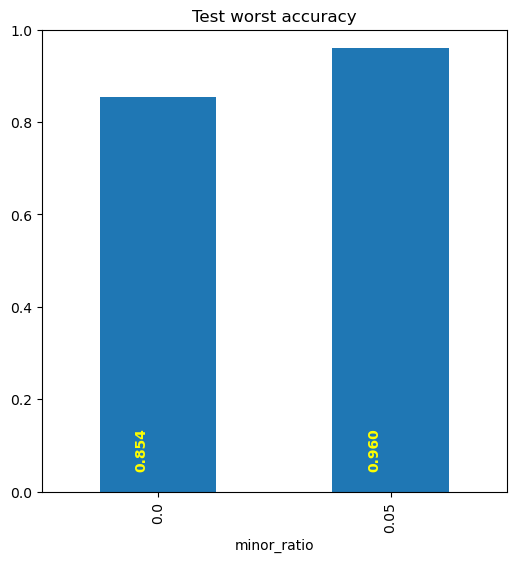

In [15]:
idx = get_best_index(df_queried_erm, var_list, 'valid_valid_best_worst_acc')

best_mean_erm = get_mean_with_given_index(df_queried_erm, var_list, 'test_worst_acc', idx)
best_std_erm = get_std_with_given_index(df_queried_erm, var_list, 'test_worst_acc', idx)
erm_test_acc_mean = get_mean_with_given_index(df_queried_erm, var_list, 'test_acc', idx)
erm_test_acc_std = get_std_with_given_index(df_queried_erm, var_list, 'test_acc', idx)

fig, ax = plt.subplots(1,1, figsize=(6,6))
xaxis= [str(i) for i in best_mean_erm.keys()]

best_mean_erm.plot(ax=ax, kind='bar', yerr=best_std_erm, capsize=7, title='Test worst accuracy', ylim=(0.0, 1))

for i, v in enumerate(best_mean_erm.values):
    ax.text(i - 0.1 , 0.05, str(f'{v:.3f}'), color='yellow', fontweight='bold', rotation=90)

fig.show()

# 2. Shell scripts for RRClarC

In [ ]:
query = ' and '.join(
    [
        'model == "convnext_t"',
        'module_name == "CGR"'
    ]
)

df_queried_rrc = df.query(query)

# A list of important columns, where hparams values are between 2 to 6.
important_columns = (df_queried_rrc.nunique() > 1) & (df.nunique() < 11)
important_columns = [i for i in df_queried_rrc.columns[important_columns] if 'acc' not in i]
print(important_columns)
print()
# print the unique values of the important columns
product = 1
for i in df_queried_rrc[important_columns]:
    product *= len(df[i].unique())
    print(i, end=' = ')
    print(df_queried_rrc[i].unique())
print()
print('Product of unique values of important columns: ', product)

In [ ]:
var_list = ['data_seed', 'minor_ratio', 'lamb_cs']
index = var_list.copy()
index.remove('data_seed')
columns = ['data_seed']

df_queried_rrc = df_queried_rrc.sort_values(by=var_list)


In [ ]:
values = ['valid_valid_best_worst_acc']
df_pivot = df_queried_rrc.pivot_table(index=index, columns=columns, values=values)
df_group = df_queried_rrc.groupby(index)['valid_valid_best_worst_acc'].apply(mean_std)
df_cat = pd.concat((df_pivot, df_group), axis=1)
df_cat.columns = pd.Index([('valid_valid_best_worst_acc', i) for i in range(1234, 1237)] + [('valid_valid_best_worst_acc', 'mean std')])
df_cat

In [ ]:
values = ['test_worst_acc']
df_pivot = df_queried_rrc.pivot_table(index=index, columns=columns, values=values)
df_group = df_queried_rrc.groupby(index)['test_worst_acc'].apply(mean_std)
df_cat = pd.concat((df_pivot, df_group), axis=1)
df_cat.columns = pd.Index([('test_worst_acc', i) for i in range(1234, 1237)] + [('test_worst_acc', 'mean std')])
df_cat

# 3. CGR results

In [ ]:
idx = get_best_index(df_queried_rrc, var_list, 'valid_valid_best_worst_acc')

best_mean_cgr = get_mean_with_given_index(df_queried_rrc, var_list, 'test_worst_acc', idx)
best_std_cgr = get_std_with_given_index(df_queried_rrc, var_list, 'test_worst_acc', idx)
cgr_test_acc_mean = get_mean_with_given_index(df_queried_rrc, var_list, 'test_acc', idx)
cgr_test_acc_std = get_std_with_given_index(df_queried_rrc, var_list, 'test_acc', idx)

fig, ax = plt.subplots(1,1, figsize=(6,6))
xaxis= [str(i) for i in best_mean_cgr.keys()]

best_mean_cgr.plot(ax=ax, kind='bar', yerr=best_std_cgr, capsize=7, title='Test worst accuracy', ylim=(0.0, 1))

for i, v in enumerate(best_mean_cgr.values):
    ax.text(i - 0.1 , 0.05, str(f'{v:.3f}'), color='yellow', fontweight='bold', rotation=90)

fig.show()

# Total

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,6))

best_model_mean = pd.concat([best_mean_erm, best_mean_cgr], axis=1)
best_model_mean.columns = ['ERM', 'CGR']
best_model_std = pd.concat([best_std_erm, best_std_cgr], axis=1)

best_model_mean.plot(ax=ax, kind='bar', yerr=best_model_std.T.to_numpy(), capsize=7, title='Test worst accuracy', ylim=(0.0, 1))

for i, vs in enumerate(best_model_mean.values):
    for j, v in enumerate(vs):
        if j == 0:
            ax.text(i - 0.15 , 0.05, str(f'{v:.3f}'), color='white', fontweight='bold', rotation=90)

        if j == 1:
            ax.text(i + 0.05 , 0.05, str(f'{v:.3f}'), color='white', fontweight='bold', rotation=90)

fig.show()

# 4. Group DRO results

In [ ]:
def mean_std(x):
    return f'{100*x.mean():.3f}+{100*x.std():.3f}'

var_list = ['minor_ratio', 'batch_size_train', 'learning_rate', 'weight_decay', 'data_seed', 'h_softplus_beta', 'eta']

df_temp = df.sort_values(by=var_list)

bs = [16, 32]
lr = [1e-4, 3e-4, 1e-3, 3e-3]
seed = [1234, 1235, 1236]
beta = [10]
mr = [0, 0.005, 0.01, 0.05]
ll = ['linear', 'three_layer']
wd = [1e-3, 1e-2]
# eta = [3e-3, 1e-2, 3e-2, 1e-1, 3e-1]

df_temp = df_temp.query(
    ' and '.join(
        [
            'model == "convnext_t"',
            'module_name == "GDRO"',
            'minor_ratio == @mr',
            'optimizer == "adamw"',
            'batch_size_train == @bs',
            'learning_rate == @lr',
            'weight_decay == @wd',
            'data_seed == @seed',
            'h_softplus_beta == @beta',
            'set_last_layer == @ll',
            # 'eta == @eta'
        ]
    )
)


var_list.remove('data_seed')
index = var_list
columns = ['data_seed']
values = ['test_worst_acc']

df_pivot = df_temp.pivot_table(index=index, columns=columns, values=values)

var_list = ['minor_ratio', 'batch_size_train', 'learning_rate', 'weight_decay', 'h_softplus_beta', 'eta']
df_group = df_temp.groupby(var_list)['test_worst_acc'].apply(mean_std)
df_cat = pd.concat((df_pivot, df_group), axis=1)
df_cat.columns = pd.Index([('test_worst_acc', i) for i in range(1234, 1237)] + [('test_worst_acc', 'mean std')])
df_cat

In [ ]:
def get_best_index(df, var_list, metric):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    idx = df_mean.reset_index().groupby(['minor_ratio']).idxmax()[metric].dropna()
    return idx

def get_mean_with_given_index(df, var_list, metric, idx):
    df_mean = df.groupby(var_list)[metric].mean().sort_index()
    return df_mean.reset_index().loc[idx].set_index('minor_ratio')[metric]

def get_std_with_given_index(df, var_list, metric, idx):
    df_std = df.groupby(var_list)[metric].std().sort_index()
    return df_std.reset_index().loc[idx].set_index('minor_ratio')[metric]


idx = get_best_index(df_temp, var_list, 'valid_valid_best_worst_acc')

best_mean_dro = get_mean_with_given_index(df_temp, var_list, 'test_worst_acc', idx)
best_std_dro = get_std_with_given_index(df_temp, var_list, 'test_worst_acc', idx)
dro_test_acc_mean = get_mean_with_given_index(df_temp, var_list, 'test_acc', idx)
dro_test_acc_std = get_std_with_given_index(df_temp, var_list, 'test_acc', idx)

fig, ax = plt.subplots(1,1, figsize=(6,6))
xaxis= [str(i) for i in best_mean_dro.keys()]

best_mean_dro.plot(ax=ax, kind='bar', yerr=best_std_dro, capsize=7, title='Test worst accuracy', ylim=(0.0, 0.9))

for i, v in enumerate(best_mean_dro.values):
    ax.text(i - 0.1 , 0.05, str(f'{v:.3f}'), color='yellow', fontweight='bold', rotation=90)

fig.show()

In [ ]:
# fig, ax = plt.subplots(1,1, figsize=(6,6))

# best_model_mean = pd.concat([best_mean_erm, best_mean_cgr, best_mean_dro], axis=1)
# best_model_mean.columns = ['ERM', 'CGR', 'GDRO']
# best_model_std = pd.concat([best_std_erm, best_std_cgr, best_std_dro], axis=1)

# best_model_mean.plot(ax=ax, kind='bar', yerr=best_model_std.T.to_numpy(), capsize=7, title='Test worst accuracy', ylim=(0, 1))

# for i, vs in enumerate(best_model_mean.values):
#     for j, v in enumerate(vs):
#         ax.text(i - 0.2 + j * 0.15 , 0.15, str(f'{v:.3f}'), color='white', fontweight='bold', rotation=90)

# fig.show()

fig, ax = plt.subplots(1,1, figsize=(6,6))

best_model_mean = pd.concat([best_mean_erm, best_mean_dro], axis=1)
best_model_mean.columns = ['ERM', 'GDRO']
best_model_std = pd.concat([best_std_erm, best_std_dro], axis=1)

best_model_mean.plot(ax=ax, kind='bar', yerr=best_model_std.T.to_numpy(), capsize=7, title='Test worst accuracy', ylim=(0, 1))

for i, vs in enumerate(best_model_mean.values):
    for j, v in enumerate(vs):
        ax.text(i - 0.2 + j * 0.15 , 0.15, str(f'{v:.3f}'), color='white', fontweight='bold', rotation=90)

fig.show()

# 5. JTT

In [ ]:
def mean_std(x):
    return f'{100*x.mean():.3f}+{100*x.std():.3f}'

var_list = ['minor_ratio', 'batch_size_train', 'learning_rate', 'weight_decay', 'data_seed', 'h_softplus_beta', 'upsample_count', 'upsample_indices_path']

df_temp = df.sort_values(by=var_list)

bs = [16, 32]
lr = [1e-4, 3e-4, 1e-3, 3e-3]
seed = [1234, 1235, 1236]
beta = [10]
mr = [0, 0.005, 0.01, 0.05]
ll = ['linear', 'three_layer']
wd = [1e-3, 1e-2]

df_temp = df_temp.query(
    ' and '.join(
        [
            'model == "convnext_t"',
            'module_name == "JTT"',
            'minor_ratio == @mr',
            'optimizer == "adamw"',
            'batch_size_train == @bs',
            'learning_rate == @lr',
            'weight_decay == @wd',
            'data_seed == @seed',
            'h_softplus_beta == @beta',
            'set_last_layer == @ll'
        ]
    )
)


var_list.remove('data_seed')
index = var_list
columns = ['data_seed']
values = ['test_worst_acc']

df_pivot = df_temp.pivot_table(index=index, columns=columns, values=values)

var_list = ['minor_ratio', 'batch_size_train', 'learning_rate', 'weight_decay', 'h_softplus_beta', 'upsample_count', 'upsample_indices_path']
df_group = df_temp.groupby(var_list)['test_worst_acc'].apply(mean_std)
df_cat = pd.concat((df_pivot, df_group), axis=1)
df_cat.columns = pd.Index([('test_worst_acc', i) for i in range(1234, 1237)] + [('test_worst_acc', 'mean std')])
df_cat



In [ ]:
idx = get_best_index(df_temp, var_list, 'valid_valid_best_worst_acc')

best_mean_jtt = get_mean_with_given_index(df_temp, var_list, 'test_worst_acc', idx)
best_std_jtt = get_std_with_given_index(df_temp, var_list, 'test_worst_acc', idx)
jtt_test_acc_mean = get_mean_with_given_index(df_temp, var_list, 'test_acc', idx)
jtt_test_acc_std = get_std_with_given_index(df_temp, var_list, 'test_acc', idx)

fig, ax = plt.subplots(1,1, figsize=(6,6))
xaxis= [str(i) for i in best_mean_jtt.keys()]

best_mean_jtt.plot(ax=ax, kind='bar', yerr=best_std_jtt, capsize=7, title='Test worst accuracy', ylim=(0.0, 0.9))

for i, v in enumerate(best_mean_jtt.values):
    ax.text(i - 0.1 , 0.05, str(f'{v:.3f}'), color='yellow', fontweight='bold', rotation=90)

fig.show()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,6))

best_model_mean = pd.concat([best_mean_erm, best_mean_jtt, best_mean_cgr, best_mean_dro], axis=1)
best_model_mean.columns = ['ERM', 'JTT', 'CGR', 'GroupDRO']
best_model_std = pd.concat([best_std_erm, best_std_jtt, best_std_cgr, best_std_dro], axis=1)

best_model_mean.plot(ax=ax, kind='bar', yerr=best_model_std.T.to_numpy(), capsize=7, title='Test worst accuracy', ylim=(0, 1))

for i, vs in enumerate(best_model_mean.values):
    for j, v in enumerate(vs):
        ax.text(i - 0.23 + j * 0.12 , 0.15, str(f'{v:.3f}'), color='white', fontweight='bold', rotation=90)

fig.show()

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,6))

best_model_mean = pd.concat([erm_test_acc_mean, jtt_test_acc_mean, cgr_test_acc_mean, dro_test_acc_mean], axis=1)
best_model_mean.columns = ['ERM', 'JTT', 'CGR', 'GroupDRO']
best_model_std = pd.concat([erm_test_acc_std, jtt_test_acc_std, cgr_test_acc_std, dro_test_acc_std], axis=1)

best_model_mean.plot(ax=ax, kind='bar', yerr=best_model_std.T.to_numpy(), capsize=7, title='(Average) Test accuracy', ylim=(0, 1))

for i, vs in enumerate(best_model_mean.values):
    for j, v in enumerate(vs):
        ax.text(i - 0.23 + j * 0.12 , 0.15, str(f'{v:.3f}'), color='white', fontweight='bold', rotation=90)

fig.show()